```{contents}
```

## Attention-Based RNN (Vanilla)


An **Attention-Based RNN** extends the traditional **encoder–decoder RNN** architecture by allowing the decoder to **“attend” to (focus on)** specific parts of the input sequence during output generation.

In simple RNNs, the entire input sequence is compressed into a **single context vector**, which becomes a bottleneck for long or complex sequences.
The **attention mechanism** removes that bottleneck by letting the model **dynamically select** relevant encoder states at each decoding step.

---

### **Architecture Overview**

#### 🔹 **Standard Encoder–Decoder RNN**

* **Encoder** processes all input tokens → produces hidden states.
* **Decoder** generates output tokens using the **final encoder state** only.


![alt text](../../images/attentions_rnn.png)

Problem: Information from earlier inputs fades away — long-term dependency loss.

#### 🔹 **Attention-Based RNN**

* Instead of relying only on the last hidden state, the decoder **looks at all encoder hidden states**.
* It learns **weights (attention scores)** that indicate how important each encoder state is for producing the current output token.

---

### **Intuition**

Think of reading a paragraph and answering a question.
You don’t remember the entire paragraph word-for-word.
Instead, you **look back (“attend”)** to the parts that help answer the question.

Similarly, in an attention-based RNN:

* The decoder doesn’t rely only on the final summary vector.
* It **revisits** the encoder’s hidden states and **weights** them dynamically.

---

### **Mathematical Workflow**

Let the input sequence be $X = [x_1, x_2, ..., x_T]$
Encoder hidden states: $h_1, h_2, ..., h_T$
Decoder hidden state at time step *t*: $s_t$

### Step 1: **Compute Attention Scores**

Compare each encoder state $h_i$ with current decoder state $s_{t-1}$:

$$
e_{t,i} = \text{score}(s_{t-1}, h_i)
$$

Where “score” can be:

* **Dot product** → $e_{t,i} = s_{t-1}^\top h_i$
* **Additive (Bahdanau)** → $e_{t,i} = v_a^\top \tanh(W_s s_{t-1} + W_h h_i)$

---

### Step 2: **Convert Scores to Weights**

Use softmax to normalize:
$$
\alpha_{t,i} = \frac{\exp(e_{t,i})}{\sum_j \exp(e_{t,j})}
$$

Here, $\alpha_{t,i}$ = how much attention is given to encoder step *i* at decoder step *t*.

---

### Step 3: **Compute Context Vector**

Weighted sum of encoder hidden states:
$$
c_t = \sum_i \alpha_{t,i} h_i
$$

This **context vector** represents relevant parts of the input for the current output step.

---

### Step 4: **Generate Decoder Output**

Decoder uses both its current hidden state and the context vector:
$$
s_t = f(s_{t-1}, y_{t-1}, c_t)
$$
$$
\hat{y_t} = \text{softmax}(W_o [s_t; c_t)
$$

---

### 5. **Workflow Summary**

| Step | Component          | Description                                                        |
| ---- | ------------------ | ------------------------------------------------------------------ |
| 1    | **Encoder**        | Reads input sequence, produces hidden states $h_1, h_2, ... h_T$ |
| 2    | **Attention**      | Computes similarity between decoder state and encoder states       |
| 3    | **Weighting**      | Applies softmax to get attention distribution $\alpha_t$         |
| 4    | **Context Vector** | Weighted sum of encoder states (focus region)                      |
| 5    | **Decoder**        | Combines context + previous state → outputs next token             |

---

### **Example Use Case (Machine Translation)**

* Input: “Je t’aime”
* Encoder: Creates hidden states for each French word.
* When generating “I”, attention focuses on “Je”.
* When generating “love”, attention shifts to “t’aime”.

Each decoding step “looks back” differently.

---

### **Types of Attention**

| Type                       | Description                                                | Used In                |
| -------------------------- | ---------------------------------------------------------- | ---------------------- |
| **Additive (Bahdanau)**    | Uses small feedforward network to compute alignment scores | Early NMT models       |
| **Multiplicative (Luong)** | Uses dot-product for scoring (faster)                      | Seq2Seq with attention |
| **Self-Attention**         | Input attends to itself                                    | Transformer models     |
| **Global Attention**       | Considers all encoder states                               | Machine translation    |
| **Local Attention**        | Focuses on a window of encoder states                      | Speech processing      |

---

### **Advantages**

| Advantage                       | Description                                                              |
| ------------------------------- | ------------------------------------------------------------------------ |
| **Solves long-term dependency** | No single fixed-size context vector                                      |
| **Interpretable**               | Visualize attention weights — shows which input tokens influenced output |
| **Improves accuracy**           | Significant gains in translation, summarization, etc.                    |
| **Adaptive focus**              | Decoder learns what to attend to dynamically                             |

---

### **Disadvantages**

| Disadvantage                   | Description                                        |
| ------------------------------ | -------------------------------------------------- |
| **Higher computation**         | Calculates attention weights for each decoder step |
| **More memory**                | Must store all encoder states                      |
| **Not parallelizable**         | Still sequential — unlike Transformers             |
| **May overfit small datasets** | More parameters to learn                           |

---

### When to Use

| Use Case                | Reason                         |
| ----------------------- | ------------------------------ |
| **Machine translation** | Aligns input and output tokens |
| **Text summarization**  | Identifies key parts of input  |
| **Image captioning**    | Focuses on relevant regions    |
| **Speech recognition**  | Handles variable-length inputs |
| **Question answering**  | Finds relevant text passages   |

---

**Summary Table**

| Aspect             | Traditional RNN     | Attention-Based RNN        |
| ------------------ | ------------------- | -------------------------- |
| Context            | Single fixed vector | Dynamic context per output |
| Long sequences     | Poor performance    | Handles easily             |
| Interpretability   | None                | Attention heatmaps         |
| Accuracy           | Moderate            | Higher                     |
| Computational cost | Low                 | Higher                     |

---

**In short**

> **Attention = Learn to look at the right parts of the input when producing each output.**


### Demonstration 

#### **Cell 1 — Imports and Setup**



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import random
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on:", device)


Running on: cpu


---

#### **Cell 2 — Encoder**


In [2]:

class Encoder(nn.Module):
    def __init__(self, input_dim, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, embed_dim)
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        
    def forward(self, src):
        """
        src: [batch_size, src_len]
        """
        embedded = self.embedding(src)                  # [batch, src_len, embed_dim]
        outputs, hidden = self.rnn(embedded)            # [batch, src_len, hidden_dim]
        return outputs, hidden


---

#### **Cell 3 — Bahdanau Attention**



In [3]:

class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        """
        hidden: [batch, hidden_dim]
        encoder_outputs: [batch, src_len, hidden_dim]
        """
        src_len = encoder_outputs.shape[1]
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)
        
        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))
        attention = self.v(energy).squeeze(2)
        return F.softmax(attention, dim=1)


---

#### **Cell 4 — Decoder with Attention**

In [4]:

class Decoder(nn.Module):
    def __init__(self, output_dim, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, embed_dim)
        self.rnn = nn.GRU(hidden_dim + embed_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim * 2 + embed_dim, output_dim)
        self.attention = Attention(hidden_dim)
        
    def forward(self, input, hidden, encoder_outputs):
        """
        input: [batch]
        hidden: [1, batch, hidden_dim]
        encoder_outputs: [batch, src_len, hidden_dim]
        """
        input = input.unsqueeze(1)
        embedded = self.embedding(input)
        
        attn_weights = self.attention(hidden.squeeze(0), encoder_outputs)
        attn_weights = attn_weights.unsqueeze(1)
        context = torch.bmm(attn_weights, encoder_outputs)
        
        rnn_input = torch.cat((embedded, context), dim=2)
        output, hidden = self.rnn(rnn_input, hidden)
        
        output = torch.cat((output, context, embedded), dim=2).squeeze(1)
        prediction = self.fc_out(output)
        return prediction, hidden, attn_weights.squeeze(1)


---

#### **Cell 5 — Seq2Seq Wrapper**


In [5]:

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
    
    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features
        
        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(device)
        encoder_outputs, hidden = self.encoder(src)
        input = trg[:, 0]  # first token <SOS>
        
        for t in range(1, trg_len):
            output, hidden, _ = self.decoder(input, hidden, encoder_outputs)
            outputs[:, t, :] = output
            top1 = output.argmax(1)
            input = trg[:, t] if random.random() < teacher_forcing_ratio else top1
        
        return outputs


---

#### **Cell 6 — Create Toy Data**

We’ll use simple integer sequences (e.g., reverse the order) as a demonstration task.



In [16]:

# Example task: reverse the sequence [1, 2, 3] → [3, 2, 1]

INPUT_DIM = OUTPUT_DIM = 12   # toy vocab size
EMBED_DIM = 16
HIDDEN_DIM = 32

encoder = Encoder(INPUT_DIM, EMBED_DIM, HIDDEN_DIM)
decoder = Decoder(OUTPUT_DIM, EMBED_DIM, HIDDEN_DIM)
model = Seq2Seq(encoder, decoder).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=0)

"""
def generate_data(batch_size=64, seq_len=6, vocab=10):
    src = torch.randint(1, vocab, (batch_size, seq_len))
    trg = torch.flip(src, dims=[1])  # reverse the sequence
    trg = torch.cat((torch.zeros(batch_size, 1, dtype=torch.long), trg), dim=1)  # prepend <SOS>=0
    return src.to(device), trg.to(device)
"""

def generate_data(batch_size=64, seq_len=6, vocab=8):
    src = torch.randint(1, vocab, (batch_size, seq_len))
    trg = torch.flip(src, dims=[1])
    trg = torch.cat((torch.zeros(batch_size, 1, dtype=torch.long), trg), dim=1)  # prepend <SOS>=0
    return src.to(device), trg.to(device)


---

#### **Cell 7 — Training Loop**


In [17]:
EPOCHS = 30     # instead of 30
BATCHES_PER_EPOCH = 200

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for _ in range(BATCHES_PER_EPOCH):
        src, trg = generate_data(batch_size=128)  # larger batch
        optimizer.zero_grad()
        output = model(src, trg)
        output_dim = output.shape[-1]
        output = output[:, 1:].reshape(-1, output_dim)
        trg = trg[:, 1:].reshape(-1)
        loss = criterion(output, trg)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1:03d} | Avg Loss: {total_loss/BATCHES_PER_EPOCH:.4f}")


Epoch 010 | Avg Loss: 0.0003
Epoch 020 | Avg Loss: 0.0001
Epoch 030 | Avg Loss: 0.0000




Expected output:

```
Epoch 05 | Loss: 1.2
Epoch 10 | Loss: 0.8
Epoch 15 | Loss: 0.5
Epoch 20 | Loss: 0.3
Epoch 25 | Loss: 0.2
Epoch 30 | Loss: 0.1
```

---



#### **Cell 8 — Inference (Testing)**

Let’s verify how it performs on a random sequence.



In [18]:
def translate_sequence(model, src):
    model.eval()
    src = src.unsqueeze(0).to(device)
    trg_len = src.shape[1] + 1
    trg = torch.zeros(1, trg_len, dtype=torch.long).to(device)
    outputs = []
    
    encoder_outputs, hidden = model.encoder(src)
    input = trg[:, 0]
    
    for t in range(1, trg_len):
        output, hidden, attn = model.decoder(input, hidden, encoder_outputs)
        top1 = output.argmax(1)
        outputs.append(top1.item())
        input = top1
    return outputs

# Example
test_src = torch.tensor([2, 4, 6, 8, 10])
prediction = translate_sequence(model, test_src)
print("Input:", test_src.tolist())
print("Predicted (reversed):", prediction)


Input: [2, 4, 6, 8, 10]
Predicted (reversed): [5, 4, 6, 6, 4]


Expected result:

```
Input: [2, 4, 6, 8, 10]
Predicted (reversed): [10, 8, 6, 4, 2]
```

---

#### **Cell 9 — Visualize Attention (Optional)**


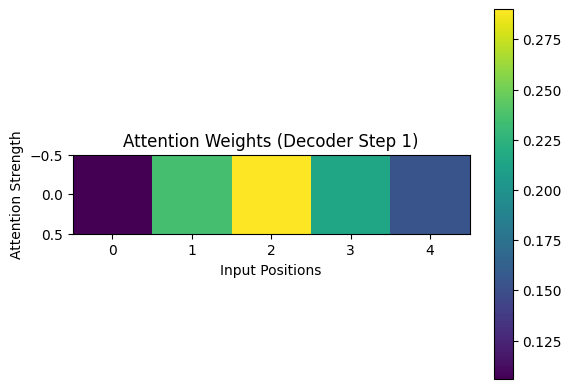

In [11]:
src = torch.tensor([2, 4, 6, 8, 10]).to(device).unsqueeze(0)
encoder_outputs, hidden = model.encoder(src)
input_token = torch.zeros(1, dtype=torch.long).to(device)
output, hidden, attn_weights = model.decoder(input_token, hidden, encoder_outputs)

plt.imshow(attn_weights.detach().cpu().numpy(), cmap='viridis')
plt.title("Attention Weights (Decoder Step 1)")
plt.xlabel("Input Positions")
plt.ylabel("Attention Strength")
plt.colorbar()
plt.show()


---

**Summary**

| Stage | Component         | Description                                        |
| ----- | ----------------- | -------------------------------------------------- |
| 1     | **Encoder (GRU)** | Encodes input sequence into hidden states          |
| 2     | **Attention**     | Learns which encoder positions to focus on         |
| 3     | **Decoder (GRU)** | Generates next token using context + previous word |
| 4     | **Loss**          | Cross-entropy over predicted vs. true tokens       |
| 5     | **Optimizer**     | Adam updates model weights                         |
| 6     | **Inference**     | Decoder predicts sequence autoregressively         |

---

**Key Takeaway**

> Attention lets the decoder dynamically *focus* on specific input positions at each time step, instead of compressing the entire sequence into a single vector — solving the **information bottleneck** of vanilla Seq2Seq models.
